# 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

# 2. Load Dataset

In [3]:
df = pd.read_csv("C:\PENS EEPIS\python\Dataset\Hitters.csv")
print(df.head())
print(df.info())

   AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  CHits  CHmRun  CRuns  \
0    293    66      1    30   29     14      1     293     66       1     30   
1    315    81      7    24   38     39     14    3449    835      69    321   
2    479   130     18    66   72     76      3    1624    457      63    224   
3    496   141     20    65   78     37     11    5628   1575     225    828   
4    321    87     10    39   42     30      2     396    101      12     48   

   CRBI  CWalks League Division  PutOuts  Assists  Errors  Salary NewLeague  
0    29      14      A        E      446       33      20     NaN         A  
1   414     375      N        W      632       43      10   475.0         N  
2   266     263      A        W      880       82      14   480.0         A  
3   838     354      N        E      200       11       3   500.0         N  
4    46      33      N        E      805       40       4    91.5         N  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Wirya\AppData\Local\Temp\ipykernel_24220\1827978527.py:1: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("C:\PENS EEPIS\python\Dataset\Hitters.csv")


# 3. Handling Missing Value

In [4]:
df = df.dropna()
print(df.isnull().sum())

AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64


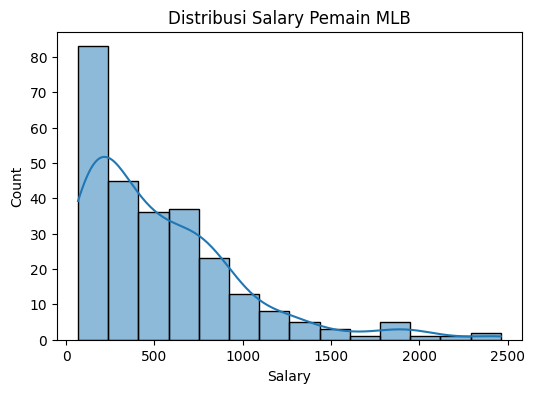

In [16]:
df = df.dropna()

plt.figure(figsize=(6,4))
sns.histplot(df['Salary'], kde=True)
plt.title("Distribusi Salary Pemain MLB")
plt.show()

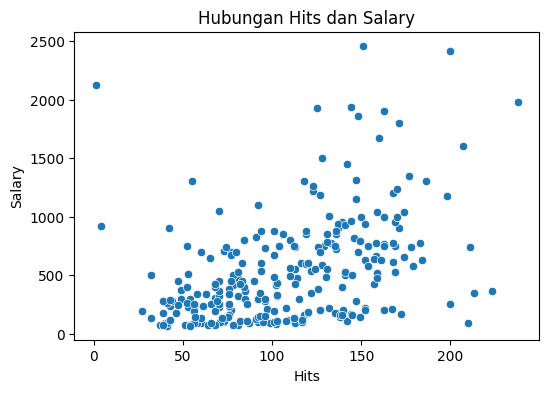

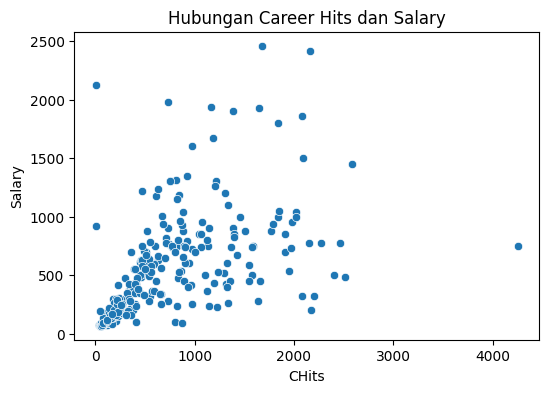

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Hits', y='Salary', data=df)
plt.title("Hubungan Hits dan Salary")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='CHits', y='Salary', data=df)
plt.title("Hubungan Career Hits dan Salary")
plt.show()

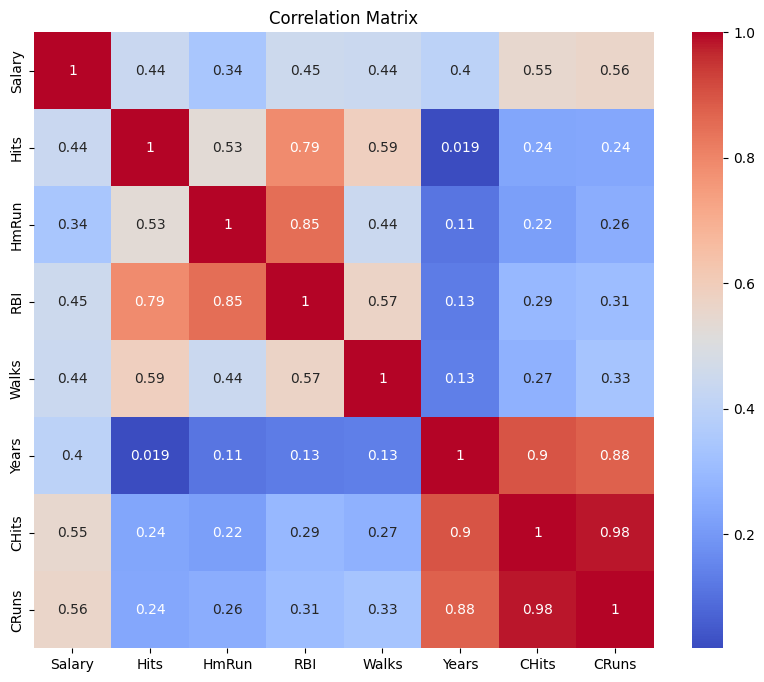

In [19]:
plt.figure(figsize=(10,8))

corr = df[['Salary','Hits','HmRun','RBI','Walks','Years','CHits','CRuns']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 4. Menentukan Variabel X dan Y

In [5]:
X = df[['Hits','HmRun','RBI','Walks','Years','CHits','CRuns']]
y = df['Salary']

# 5. Split Data Train dan Test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Model OLS 

In [7]:
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     28.14
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           7.90e-27
Time:                        21:04:37   Log-Likelihood:                -1512.2
No. Observations:                 210   AIC:                             3040.
Df Residuals:                     202   BIC:                             3067.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -113.7768     85.621     -1.329      0.1

# 7. Prediksi OLS

In [9]:
X_test_sm = sm.add_constant(X_test)

ols_pred_train = ols_model.predict(X_train_sm)
ols_pred_test = ols_model.predict(X_test_sm)

mse_train_ols = mean_squared_error(y_train, ols_pred_train)
mse_test_ols = mean_squared_error(y_test, ols_pred_test)

print("MSE Train OLS:", mse_train_ols)
print("MSE Test OLS :", mse_test_ols)

MSE Train OLS: 105286.84185522521
MSE Test OLS : 156019.0984857474


# 8. Model Ridge Regression

In [10]:
alphas = np.logspace(-3,3,100)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

print("Lambda terbaik Ridge:", ridge.alpha_)

ridge_pred_train = ridge.predict(X_train)
ridge_pred_test = ridge.predict(X_test)

mse_train_ridge = mean_squared_error(y_train, ridge_pred_train)
mse_test_ridge = mean_squared_error(y_test, ridge_pred_test)

Lambda terbaik Ridge: 1000.0


# 9. Model LASSO

In [11]:
lasso = LassoCV(alphas=np.logspace(-3,3,100), cv=5, max_iter=10000)
lasso.fit(X_train, y_train)

print("Lambda terbaik LASSO:", lasso.alpha_)

lasso_pred_train = lasso.predict(X_train)
lasso_pred_test = lasso.predict(X_test)

mse_train_lasso = mean_squared_error(y_train, lasso_pred_train)
mse_test_lasso = mean_squared_error(y_test, lasso_pred_test)

Lambda terbaik LASSO: 327.4549162877732


# 10. Model Elastic Net

In [12]:
enet = ElasticNetCV(
    alphas=np.logspace(-3,3,100),
    l1_ratio=0.5,
    cv=5,
    max_iter=10000
)

enet.fit(X_train, y_train)

print("Lambda terbaik ElasticNet:", enet.alpha_)

enet_pred_train = enet.predict(X_train)
enet_pred_test = enet.predict(X_test)

mse_train_enet = mean_squared_error(y_train, enet_pred_train)
mse_test_enet = mean_squared_error(y_test, enet_pred_test)

Lambda terbaik ElasticNet: 327.4549162877732


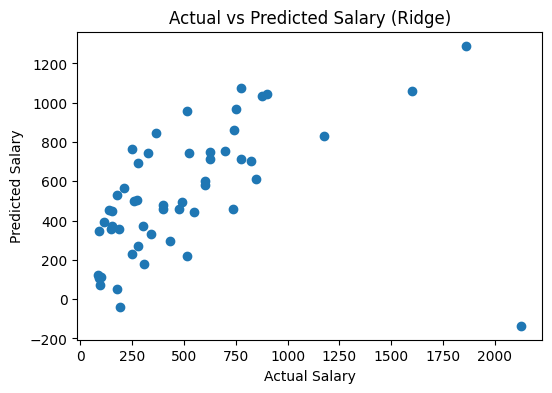

In [20]:
ridge_pred = ridge.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(y_test, ridge_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Ridge)")
plt.show()

# 11. Perbandingan Model

In [13]:
results = pd.DataFrame({
    "Model":["OLS","Ridge","LASSO","ElasticNet"],
    "MSE Train":[
        mse_train_ols,
        mse_train_ridge,
        mse_train_lasso,
        mse_train_enet
    ],
    "MSE Test":[
        mse_test_ols,
        mse_test_ridge,
        mse_test_lasso,
        mse_test_enet
    ]
})

results["RMSE Test"] = np.sqrt(results["MSE Test"])

print(results)

        Model      MSE Train       MSE Test   RMSE Test
0         OLS  105286.841855  156019.098486  394.992530
1       Ridge  105362.562026  157494.901071  396.856273
2       LASSO  105925.098504  156127.454778  395.129668
3  ElasticNet  106148.536590  154895.882456  393.568142


# 12. Koefisien Model

In [14]:
coef = pd.DataFrame({
    "Variable": X.columns,
    "Ridge": ridge.coef_,
    "LASSO": lasso.coef_,
    "ElasticNet": enet.coef_
})

print(coef)

  Variable     Ridge     LASSO  ElasticNet
0     Hits  2.314300  2.569321    2.470293
1    HmRun  1.786669  0.000000    0.000000
2      RBI  1.410345  1.492611    1.576727
3    Walks  2.845634  2.008423    1.735663
4    Years -3.287737 -0.000000   -0.000000
5    CHits  0.178862  0.096084    0.081999
6    CRuns  0.305503  0.439417    0.473783
